## **LIBRERÍAS Y MÓDULOS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, norm, chi2_contingency, shapiro, ks_2samp, ttest_ind, mannwhitneyu
from sklearn.impute import SimpleImputer, KNNImputer
import warnings

#Librerías para el modelo de clasificación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


## **LECTURA DEL DATASET**

In [2]:
df = pd.read_csv("C:\\Users\\danie\\OneDrive\\Documentos\\6to semestre\\Data Viz\\Café\\synthetic_coffee_health_10000.csv")

In [3]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Columnas del DataFrame: {df.columns.tolist()}")

Filas: 10000
Columnas: 16
Columnas del DataFrame: ['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


In [4]:
df.head(n=5)

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [5]:
columnas = list(df.columns)
columnas_numericas = list(df.select_dtypes(include=[np.number]).columns)
columnas_categoricas = list(df.select_dtypes(include=['object']).columns)

print("\nColumnas numéricas:")
print(columnas_numericas)
print("\nColumnas categóricas:")
print(columnas_categoricas)


Columnas numéricas:
['ID', 'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption']

Columnas categóricas:
['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation']


## **ESTADÍSTICAS BÁSICAS**

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.250,10000.0
Age,10000.0,34.94910,11.160939,18.0,26.00,34.0,43.000,80.0
Coffee_Intake,10000.0,2.50923,1.450248,0.0,1.50,2.5,3.500,8.2
Caffeine_mg,10000.0,238.41101,137.748815,0.0,138.75,235.4,332.025,780.3
Sleep_Hours,10000.0,6.63622,1.222055,3.0,5.80,6.6,7.500,10.0
BMI,10000.0,23.98686,3.906411,15.0,21.30,24.0,26.600,38.2
Heart_Rate,10000.0,70.61780,9.822951,50.0,64.00,71.0,77.000,109.0
Physical_Activity_Hours,10000.0,7.48704,4.315180,0.0,3.70,7.5,11.200,15.0
Smoking,10000.0,0.20040,0.400320,0.0,0.00,0.0,0.000,1.0
Alcohol_Consumption,10000.0,0.30070,0.458585,0.0,0.00,0.0,1.000,1.0


In [11]:
df.describe(include='object').T

,count,unique,top,freq
Gender,10000,3,Female,5001
Country,10000,20,Canada,543
Sleep_Quality,10000,4,Good,5637
Stress_Level,10000,3,Low,6989
Health_Issues,4059,3,Mild,3579
Occupation,10000,5,Office,2073


In [62]:
print(f"Categorias de la variable Health Issues: {df['Health_Issues'].unique()}")

Categorias de la variable Health Issues: [nan 'Mild' 'Moderate' 'Severe']


## **CONTEO Y TRATAMIENTO DE FALTANTES**

In [8]:
datos_faltantes=df.isna().sum()
print("Cantidad de datos faltantes por columna:")
print(datos_faltantes)

Cantidad de datos faltantes por columna:
ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64


In [9]:
print("Porcentaje de valores faltantes por columna: ")
print(df.isna().mean() * 100)

Porcentaje de valores faltantes por columna: 
ID                          0.00
Age                         0.00
Gender                      0.00
Country                     0.00
Coffee_Intake               0.00
Caffeine_mg                 0.00
Sleep_Hours                 0.00
Sleep_Quality               0.00
BMI                         0.00
Heart_Rate                  0.00
Stress_Level                0.00
Physical_Activity_Hours     0.00
Health_Issues              59.41
Occupation                  0.00
Smoking                     0.00
Alcohol_Consumption         0.00
dtype: float64


### **Registro visual de datos faltantes**

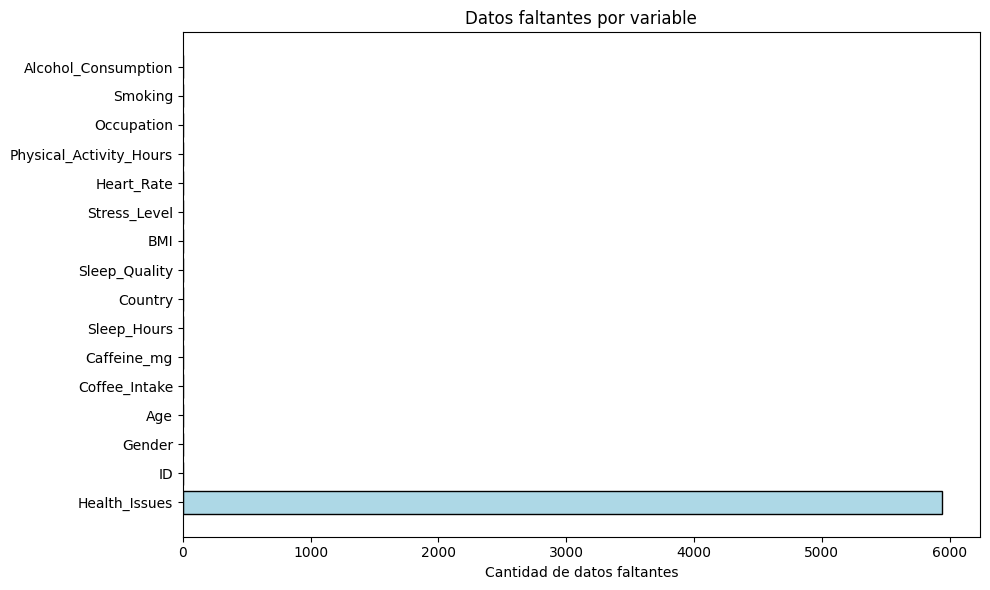

In [10]:
# Ordenar los datos faltantes de menor a mayor
datos_faltantes_ordenados = datos_faltantes.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(datos_faltantes_ordenados.index,
         datos_faltantes_ordenados.values,
         color='lightblue', edgecolor='black')

plt.xlabel("Cantidad de datos faltantes")
plt.title("Datos faltantes por variable")
plt.tight_layout()
plt.show()

### **Decisión de Imputación**

Podemos ver que la columna ```Health_Issues``` presenta un alto nivel de datos faltantes, cercano al 60%.

De acuerdo a la literatura y a las temáticas vistas en clase, hemos decidido eliminar la columna, puesto que al aplicar alguna de las técnicas de imputación vistas en clase, podría alterarse la naturaleza de la variable, generando sesgos en una columna tan importante.

In [4]:
df_tratado = df.drop('Health_Issues', axis=1)

In [13]:
columnas_tratadas = df_tratado.columns.tolist()
print("Columnas después de eliminar 'Health_Issues':", columnas_tratadas)

Columnas después de eliminar 'Health_Issues': ['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Occupation', 'Smoking', 'Alcohol_Consumption']


## **FEATURE ENGINEERING**

Dado que la variable original ``Health_Issues`` presenta un nivel de valores faltantes cercano al 60%, su utilización directa como variable objetivo comprometería gravemente la validez del modelo de clasificación. Entrenar un modelo a partir de una variable con tal nivel de ausencia de información implica:

 - Introducir sesgos severos al imputar datos sin fundamento clínico.
- Reducir la representatividad de los casos realmente observados.
- Limitar la capacidad del modelo para aprender patrones reales.

Aumentar drásticamente el riesgo de sobreajuste o conclusiones erróneas.

Por esta razón, la creación de una nueva variable objetivo mediante técnicas de feature engineering se vuelve una estrategia metodológicamente más sólida.

In [16]:
df_tratado['High_Heart_Rate'] = (df_tratado['Heart_Rate'] > 100).astype(int)
df_tratado['High_BMI'] = (df_tratado['BMI'] >= 25).astype(int)
df_tratado['Health_Risk'] = ((df_tratado['Heart_Rate'] > 100) | (df_tratado['BMI'] >= 25)).astype(int)

In [18]:
df_tratado.tail(n=5)

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption,High_Heart_Rate,High_BMI,Health_Risk
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Healthcare,0,1,0,1,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Service,0,0,0,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,Student,1,1,0,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,Student,0,0,0,0,0
9999,10000,42,Female,Brazil,2.9,277.5,6.4,Good,28.1,72,Low,9.8,Student,1,0,0,1,1


A partir de este proceso, hemos construido una nueva variable objetivo, llamada ``Health Risk``.

Mediante esta imputación, buscamos predecir si una persona experimentará problemas de salud basándonos en si tiene un Ritmo Cardíaco alto ( Pulsaciones > 100 por minuto ) ó un índice de Masa Muscular Elevado. 

La ventaja de este método radica en que la característica a predecir está determinada por todos los registros completos y no en técnicas de imputación que pueden introducir sesgos.

## **ANÁLISIS UNIVARIADO**

### **Distribución de Columnas Numéricas (No binarias)**

En este apartado se analiza la distribución por medio de histogramas y gráficos Q-Q de columnas numéricas (Discretas y Continuas)

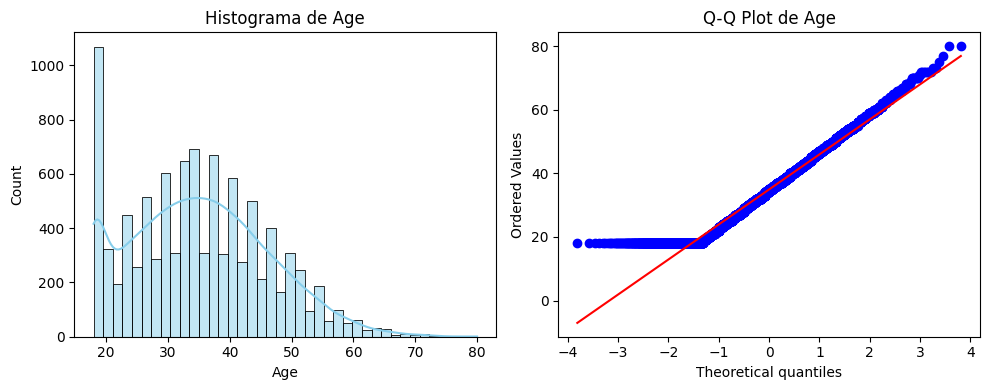

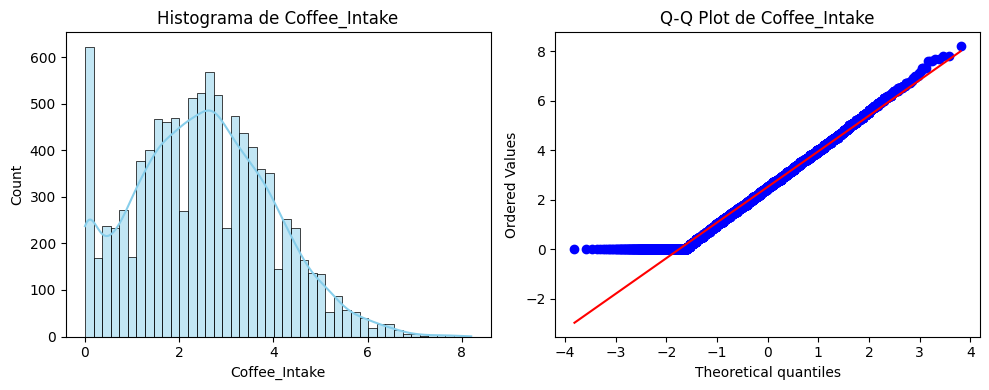

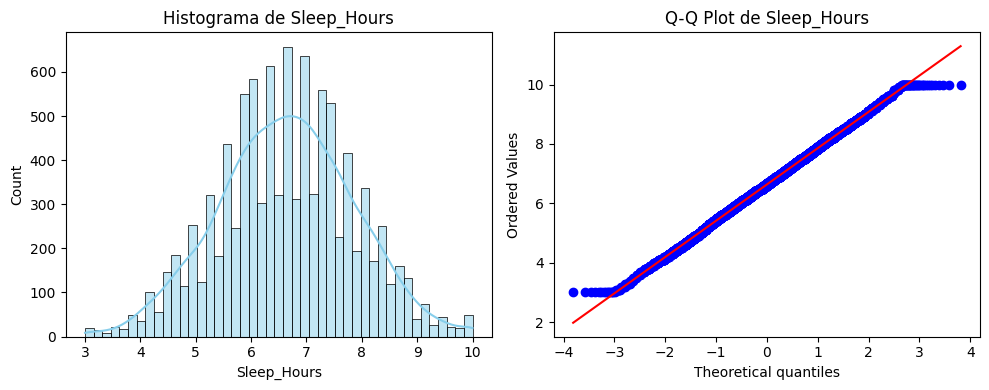

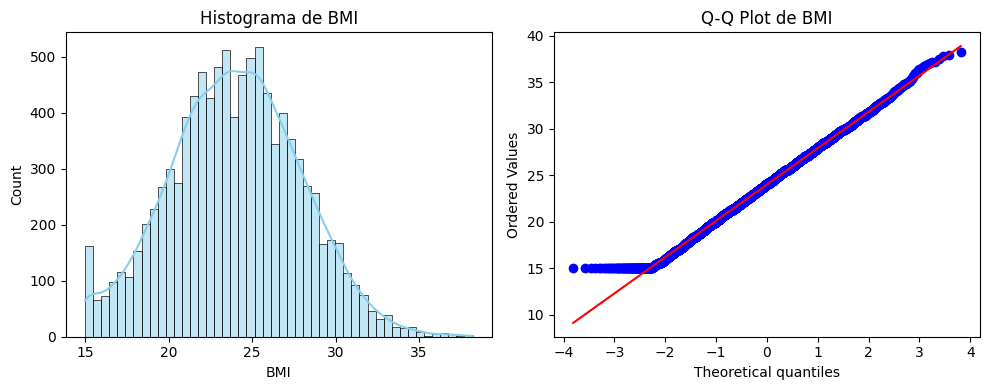

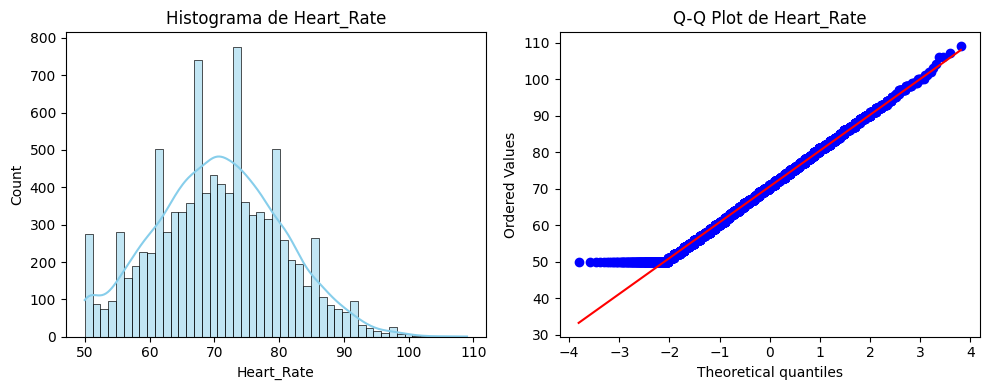

In [23]:
# Distribución de variables numéricas
numerical_cols = ['Age', 'Coffee_Intake', 'Sleep_Hours', 'BMI', 'Heart_Rate']
#numerical_cols = df_tratado.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df_tratado[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Histograma de {col}')
    
    plt.subplot(1, 2, 2)
    stats.probplot(df_tratado[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {col}')
    
    plt.tight_layout()
    plt.show()

### **Análisis de Outliers**

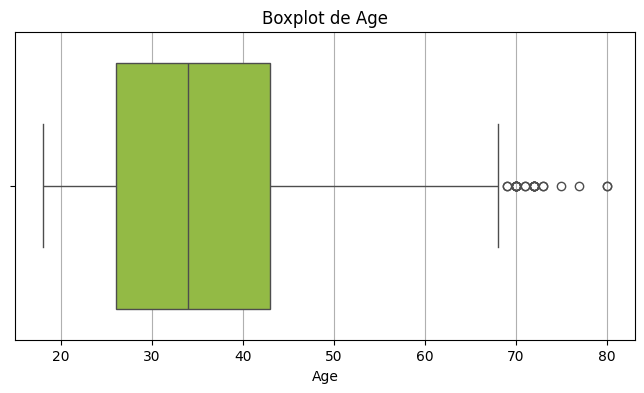

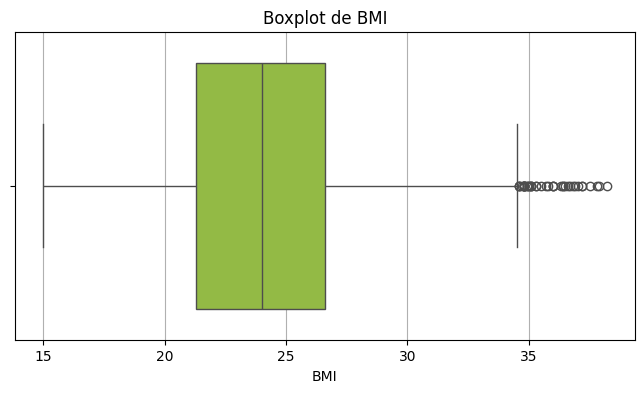

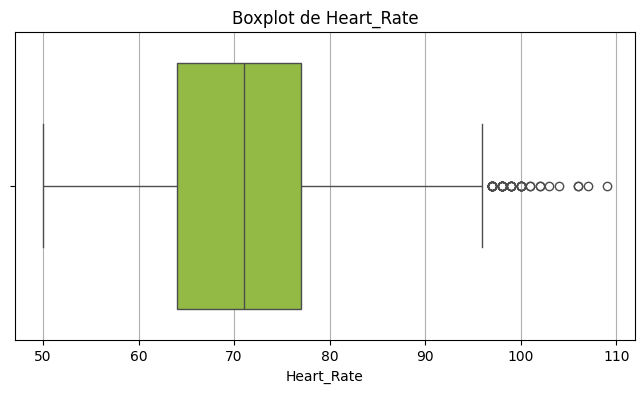

In [33]:
cols_boxplot = ['Age', 'BMI', 'Heart_Rate']
for col in cols_boxplot:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_tratado[col], color='yellowgreen')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True, axis='x')
    plt.show()
    

In [39]:
#Conteo de outliers
# Lista de columnas numéricas a analizar
cols_boxplot = ['Age', 'Coffee_Intake', 'Sleep_Hours', 'BMI', 'Heart_Rate']

outlier_stats = {}

for col in cols_boxplot:
    Q1 = df_tratado[col].quantile(0.25)
    Q3 = df_tratado[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites inferior y superior
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificación de outliers
    outliers = df_tratado[(df_tratado[col] < lower_bound) | (df_tratado[col] > upper_bound)][col]
    
    # Cálculo de métricas
    count_outliers = outliers.shape[0]
    percent_outliers = (count_outliers / df_tratado.shape[0]) * 100
    
    outlier_stats[col] = {
        "Outliers": count_outliers,
        "Porcentaje (%)": round(percent_outliers, 2)
    }

# Mostrar resultados en un DataFrame bonito
outlier_df = pd.DataFrame(outlier_stats).T
outlier_df


,Outliers,Porcentaje (%)
Age,25.0,0.25
Coffee_Intake,39.0,0.39
Sleep_Hours,26.0,0.26
BMI,40.0,0.40
Heart_Rate,50.0,0.50


In [42]:
for col in cols_boxplot:
    print(f"Mínimo valor en {col}: {df_tratado[col].min()}")
    print(f"Máximo valor en {col}: {df_tratado[col].max()}")
    

Mínimo valor en Age: 18
Máximo valor en Age: 80
Mínimo valor en Coffee_Intake: 0.0
Máximo valor en Coffee_Intake: 8.2
Mínimo valor en Sleep_Hours: 3.0
Máximo valor en Sleep_Hours: 10.0
Mínimo valor en BMI: 15.0
Máximo valor en BMI: 38.2
Mínimo valor en Heart_Rate: 50
Máximo valor en Heart_Rate: 109


Cómo es evidente, las variables numéricas que le dan una mayor interpretabilidad al modelo no presentan una gran cantidad de atípicos. 

Más aún, los valores atípicos, no resultan anormales, sino que por otro lado, corresponden a registros válidos, porque por ejemplo, es posible que una persona duerma 3H y que otra tenga una Frecuencia Cardiaca de 50 lpm

## **Análisis Bivariado**

### **Coffee Intake vs Stress Levels**

C:\Users\danie\AppData\Local\Temp\ipykernel_24360\3932702663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tratado, x='Stress_Level', y='Coffee_Intake', palette='Set2')


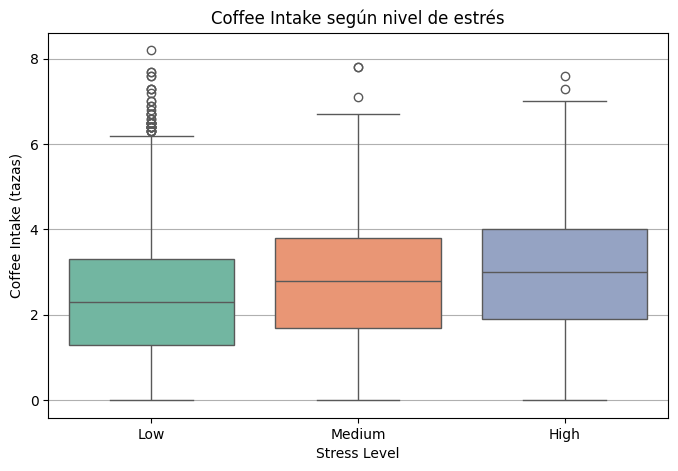

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tratado, x='Stress_Level', y='Coffee_Intake', palette='Set2')
plt.title("Coffee Intake según nivel de estrés")
plt.xlabel("Stress Level")
plt.ylabel("Coffee Intake (tazas)")
plt.grid(axis='y')
plt.show()


### **Sleep Hours vs Heart_Rate**

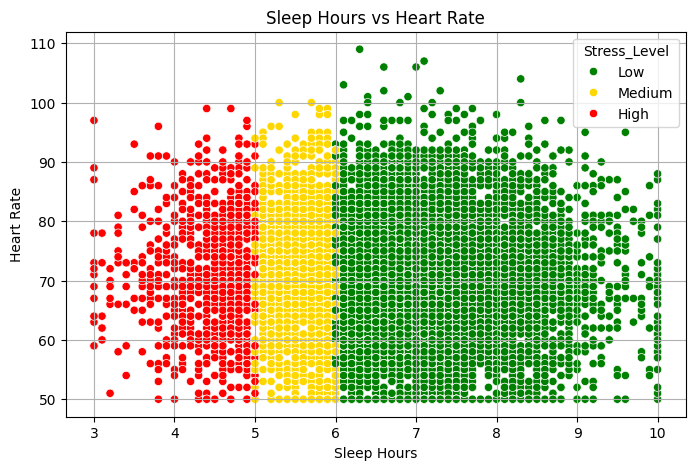

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tratado, x='Sleep_Hours', y='Heart_Rate', hue='Stress_Level', palette = ["green", "gold", "red"])
plt.title("Sleep Hours vs Heart Rate")
plt.xlabel("Sleep Hours")
plt.ylabel("Heart Rate")
plt.grid(True)
plt.show()